# 3.3 — The Chain Rule, at the computer

Do the **pen-and-paper worksheet first**. Here you'll build a pipeline of functions, measure
each stage's sensitivity separately, multiply them — and watch the product match a direct
end-to-end nudge. That experiment *is* backpropagation in miniature.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def derivative(f, x, h=1e-6):        # the nudge machine, as always
    return (f(x + h) - f(x)) / h

## 1. The experiment: do sensitivities really multiply?

Pipeline from the lesson: $x \to g \to f$ where $g(x) = 3x+1$ and $f(u) = u^2$.
We'll measure at $x = 1$:

1. the inner stage's sensitivity, $g'(1)$
2. the outer stage's sensitivity **at the value $g$ hands it**, $f'(g(1))$
3. their product
4. the *direct* end-to-end sensitivity of the whole pipe

If the chain rule is real, 3 and 4 must agree.

In [2]:
def g(x):
    return 3*x + 1

def f(u):
    return u**2

def pipeline(x):
    return f(g(x))            # machines feeding machines — Module 1.4

x0 = 1
inner = derivative(g, x0)             # sensitivity of stage 1
outer = derivative(f, g(x0))          # sensitivity of stage 2, AT g(x0) = 4
print("inner g' at x=1        ≈", round(inner, 4))
print("outer f' at g(1)=4     ≈", round(outer, 4))
print("multiplied along pipe  ≈", round(inner * outer, 4))
print("direct end-to-end nudge≈", round(derivative(pipeline, x0), 4))

inner g' at x=1        ≈ 3.0
outer f' at g(1)=4     ≈ 8.0
multiplied along pipe  ≈ 24.0
direct end-to-end nudge≈ 24.0


Same number, two roads. Backprop takes the first road — measuring stage by stage and
multiplying backwards — because for a million-weight network it's astronomically cheaper
than nudging every weight one at a time.

In [3]:
# YOUR TURN — rerun the experiment for worksheet problem 6: h(x) = (x² + 1)⁴ at x = 1.
# Define the stages, measure each sensitivity, multiply, then nudge end-to-end.

def g2(x):
    return 0   # <- fix me: the inner stage

def f2(u):
    return 0   # <- fix me: the outer stage

# inner2 = ...
# outer2 = ...          (careful: measured AT g2(1), not at 1)
# print(inner2 * outer2, "should match", derivative(lambda v: f2(g2(v)), 1))
# `lambda v: ...` is a one-line unnamed function — handy for quick pipelines.

## 2. The symbolic referee

`sympy` applies the chain rule internally. Check your Part B answers:

In [4]:
x = sp.symbols("x")

print("P5: ", sp.diff((2*x + 5)**3, x))
print("P7: ", sp.diff(sp.exp(3*x), x))
print("P9: ", sp.diff(sp.exp(-x**2), x))

# YOUR TURN — add checks for problems 6, 8 and 10, and the sigmoid from Part D:
# print(sp.diff(1/(1 + sp.exp(-x)), x))

P5:  6*(2*x + 5)**2
P7:  3*exp(3*x)
P9:  -2*x*exp(-x**2)


## 3. 🌀 Why deep learning nearly didn't happen

Worksheet problem 16, made visible. A deep network is a LONG pipe, and the end-to-end
sensitivity is the **product** of every stage's. Watch what repeated multiplication does
as the pipe gets deeper:

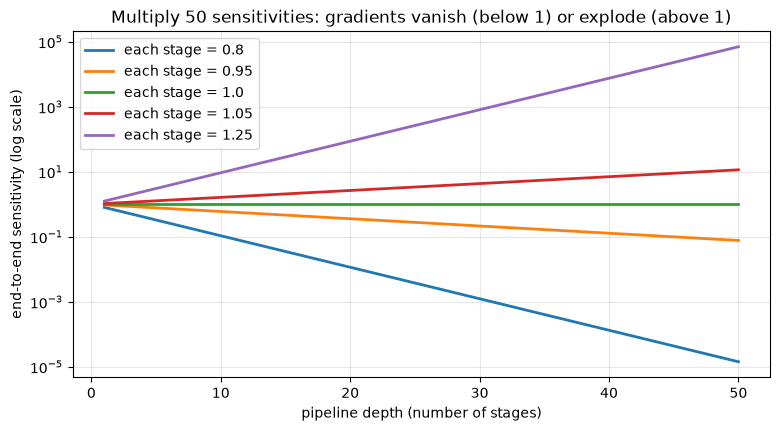

In [5]:
depths = np.arange(1, 51)              # pipes 1 to 50 stages long

plt.figure(figsize=(9, 4.5))
for s in [0.8, 0.95, 1.0, 1.05, 1.25]: # each stage's sensitivity
    plt.plot(depths, s**depths, linewidth=2, label=f"each stage = {s}")
plt.yscale("log")                       # log scale — Module 0.5 earning its keep
plt.xlabel("pipeline depth (number of stages)")
plt.ylabel("end-to-end sensitivity (log scale)")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Multiply 50 sensitivities: gradients vanish (below 1) or explode (above 1)")
plt.show()

Only sensitivities balanced near 1 survive a deep pipe — everything else starves to zero or
blows up. For decades this maths kept networks shallow. The fixes (ReLU activations, residual
connections, careful initialisation) are all engineering answers to *this exact plot*.
You now understand a real, famous problem in AI — from one multiplication.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 3.4 — many inputs at once: partials and the gradient.*